In [1]:
import pickle, os, pathlib
import pandas as pd
import numpy as np
from highz_exp.spec_class import Spectrum
import matplotlib.pyplot as plt
from highz_exp import plotter
from highz_exp.load_db import get_T_data

%load_ext autoreload
%autoreload 2

## Instructions

This notebook is used to visualize the results of tools/ds_cal_wf.py, which computes the system gain and temperature per cycle. The results are stored into a pickle file, which is loaded and visualized in this notebook.

In [2]:
with open(pathlib.Path("/home/peterson_lab/highz2026/calibrated_data/20260303_combined_segments.pkl"), "rb") as f:
    combined_segments = pickle.load(f)

In [3]:
len(combined_segments[0]['ant_T_wf'])

17550

In [4]:
print(list(combined_segments[0].keys()))

['resistor_median_spec', 'nd_median_spec', 'antenna_median_spec', 'system_temp_spec', 'sys_gain_db_spec', 'segment_label', 'calibrator_data', 'gain_per_cycle', 'system_temp_per_cycle', 'ant_T_wf', 'ant_T_sample_spec', 'antenna_utc_timestamps', 'frequencies_mhz']


In [5]:
from highz_exp.unit_convert import convert_utc_list_to_local

In [6]:
convert_utc_list_to_local(combined_segments[0]['antenna_utc_timestamps'], 
    local_timezone='Pacific/Honolulu')

array([datetime.datetime(2026, 3, 2, 14, 28, 22, tzinfo=zoneinfo.ZoneInfo(key='Pacific/Honolulu')),
       datetime.datetime(2026, 3, 2, 14, 28, 25, tzinfo=zoneinfo.ZoneInfo(key='Pacific/Honolulu')),
       datetime.datetime(2026, 3, 2, 14, 28, 27, tzinfo=zoneinfo.ZoneInfo(key='Pacific/Honolulu')),
       ...,
       datetime.datetime(2026, 3, 3, 2, 28, 29, tzinfo=zoneinfo.ZoneInfo(key='Pacific/Honolulu')),
       datetime.datetime(2026, 3, 3, 2, 28, 31, tzinfo=zoneinfo.ZoneInfo(key='Pacific/Honolulu')),
       datetime.datetime(2026, 3, 3, 2, 28, 33, tzinfo=zoneinfo.ZoneInfo(key='Pacific/Honolulu'))],
      shape=(17550,), dtype=object)

In [7]:
ant_T = combined_segments[0]['ant_T_wf']
f_mhz = combined_segments[0]['frequencies_mhz']

In [12]:
cal_data = combined_segments[0]['calibrator_data']

In [13]:
R_T = [cal_data['resistor'][i][1] for i in range(len(cal_data['resistor']))]
R_power = [cal_data['resistor'][i][0] for i in range(len(cal_data['resistor']))]
ND_power = [cal_data['noise_diode'][i][0] for i in range(len(cal_data['noise_diode']))]

In [14]:
cycle_sys_temp = combined_segments[0]['system_temp_per_cycle']
list_of_sys_specs = [Spectrum(frequency=f_mhz*1e6, 
    spectrum=cycle_sys_temp[i], name="System Temperature") for i in range(cycle_sys_temp.shape[0])]

In [15]:
cycle_sys_gain = combined_segments[0]['gain_per_cycle']
list_of_gain_specs = [Spectrum(frequency=f_mhz*1e6,
    spectrum=np.log10(cycle_sys_gain[i])*10, name="System Gain") for i in range(cycle_sys_gain.shape[0])]

In [16]:
list_of_resis_power = [Spectrum(frequency=f_mhz*1e6,
    spectrum=R_power[i], name="Resistor Power") for i in range(len(R_power))]
list_of_nd_power = [Spectrum(frequency=f_mhz*1e6,
    spectrum=ND_power[i], name="Noise Diode Power") for i in range(len(ND_power))]

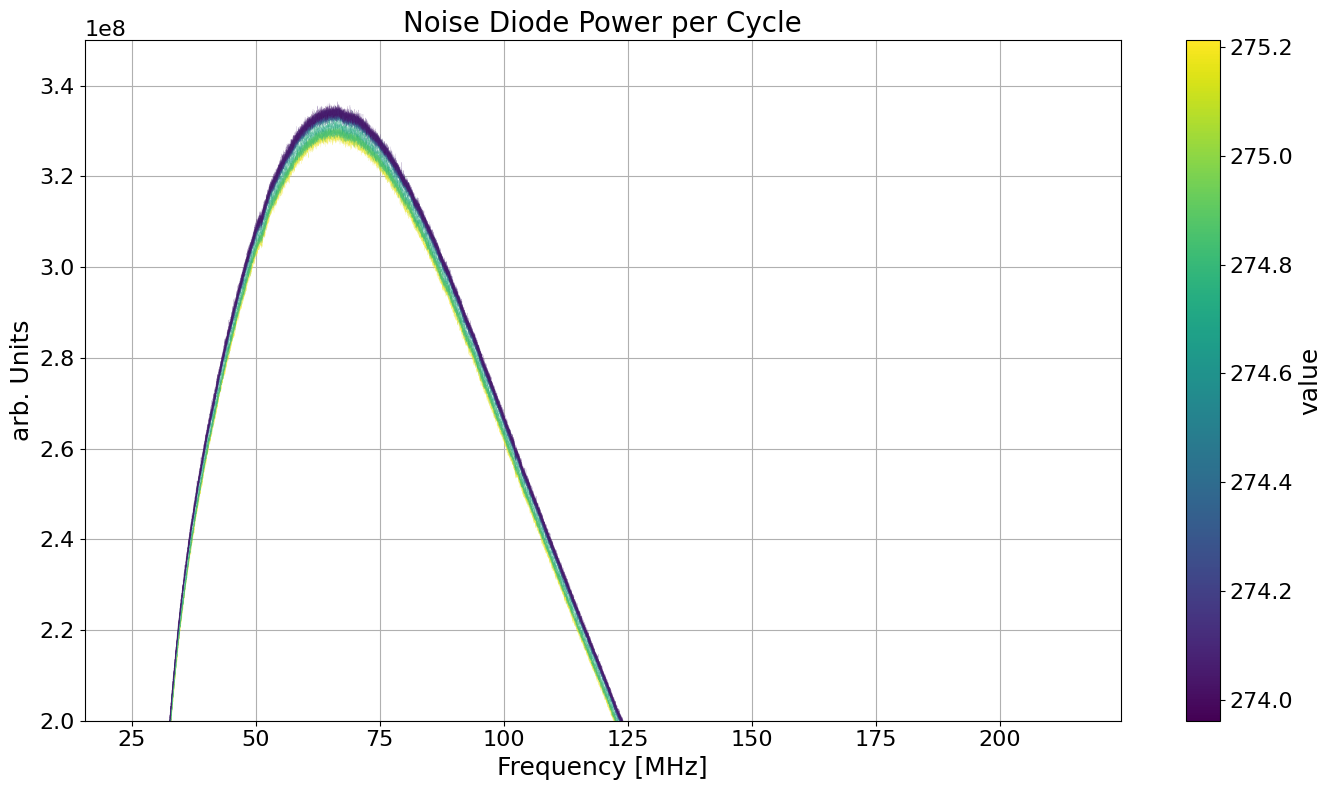

In [17]:
plotter.plot_spaghetti_spectra(list_of_nd_power, values=R_T, y_range=(2.0e8, 3.5e8),
        title="Noise Diode Power per Cycle", ylabel='arb. Units')

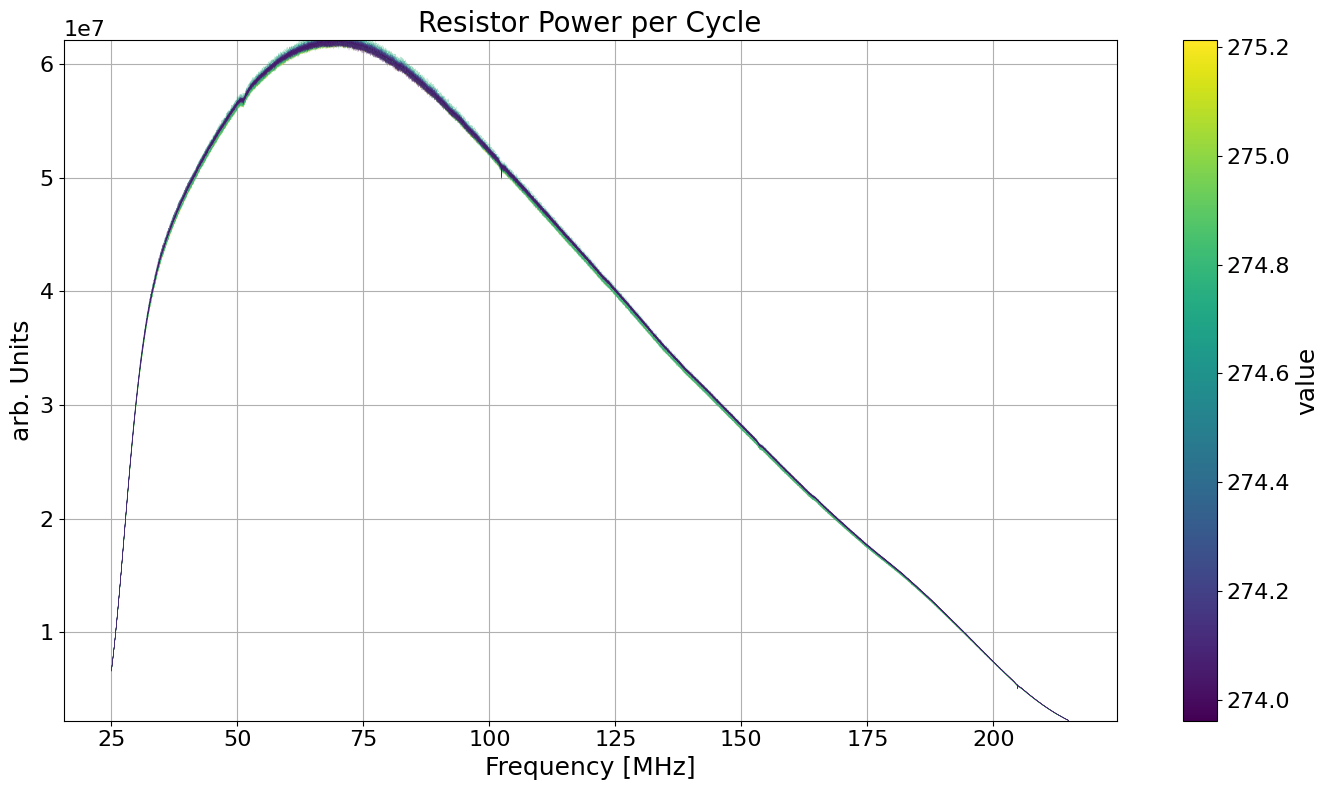

In [18]:
plotter.plot_spaghetti_spectra(list_of_resis_power, values=R_T,
        title="Resistor Power per Cycle", ylabel='arb. Units')

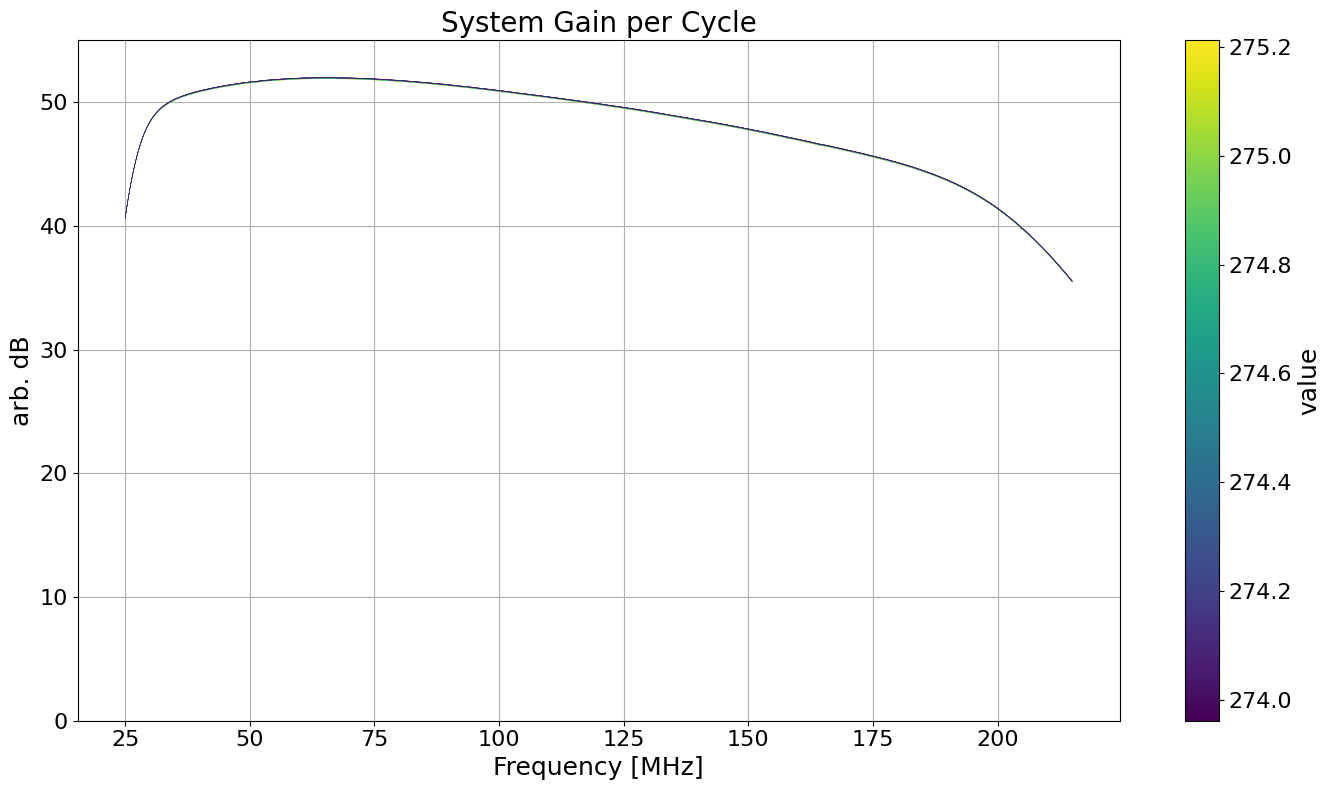

In [19]:
plotter.plot_spaghetti_spectra(list_of_gain_specs, values=R_T,
        title="System Gain per Cycle", ylabel='arb. dB', y_range=(0, 55))

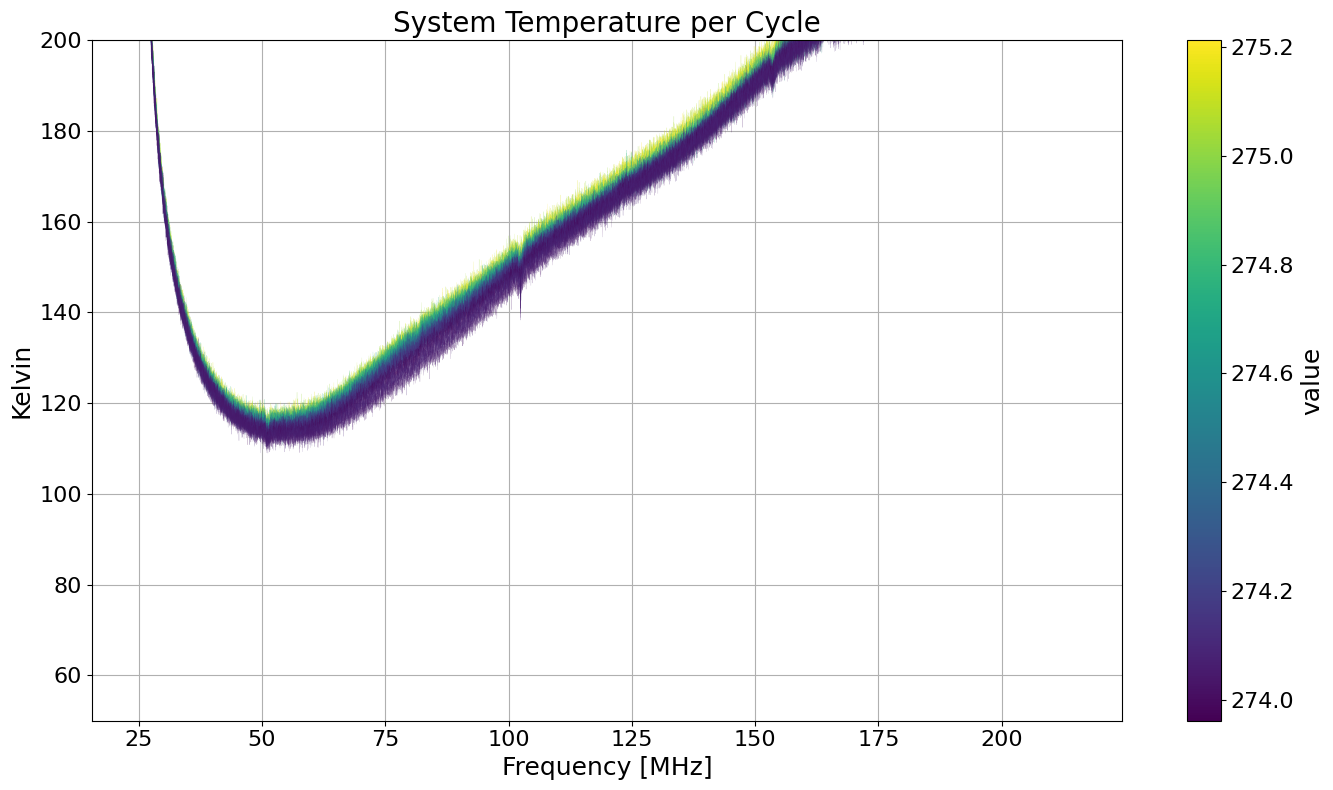

In [20]:
plotter.plot_spaghetti_spectra(list_of_sys_specs, values=R_T,
        title="System Temperature per Cycle", ylabel='Kelvin', y_range=(50, 200))